# Análise Exploratória de Dados — Consumo Mundial de Energia
## Desenvolvimento Econômico e Transição para Energias Renováveis

**Dataset:** World Energy Consumption — Our World in Data  
 Relação entre PIB per capita e adoção de energia renovável por continente (2000–2022)

---
 UNIFEI  
**Bibliotecas utilizadas:** `pandas`, `numpy`, `matplotlib`, `seaborn`


---
## Etapa 1 — Entendimento dos Dados

### 1.1 Contexto e Objetivo

O dataset **World Energy Consumption**, mantido pelo *Our World in Data* (OWID), agrega dados históricos de produção, consumo e geração de energia por país, compilados a partir de fontes primárias como *BP Statistical Review*, *International Energy Agency (IEA)* e *Ember*. A base possui **130 variáveis** e cobre mais de 200 países desde meados do século XX.

O **objetivo desta análise** é investigar se existe relação entre o nível de desenvolvimento econômico de um país (mensurado pelo PIB per capita) e a proporção de energia renovável em sua matriz energética, comparando esse padrão entre continentes.

---

### 1.2 Descrição e Classificação das Variáveis-Chave

| Variável no Dataset | Nome Descritivo | Tipo Estatístico |
|---|---|---|
| `country` | País | **Qualitativa Nominal** — identifica a unidade geográfica sem ordenação |
| `continent` | Continente | **Qualitativa Nominal** — agrupa países por região geográfica, sem hierarquia |
| `year` | Ano | **Quantitativa Discreta** — valores inteiros que representam períodos |
| `gdp` | PIB Total (USD 2011 PPP) | **Quantitativa Contínua** — riqueza total produzida, assume qualquer valor positivo |
| `population` | População | **Quantitativa Discreta** — contagem de indivíduos (inteiros) |
| `fossil_fuel_consumption` | Consumo de Combustíveis Fósseis (TWh) | **Quantitativa Contínua** — energia consumida de fontes não renováveis |
| `renewables_consumption` | Consumo de Renováveis (TWh) | **Quantitativa Contínua** — energia consumida de fontes renováveis |
| `renewables_share_energy` | Participação Renovável (%) | **Quantitativa Contínua** — percentual no consumo total de energia |
| `greenhouse_gas_emissions` | Emissões de CO₂ equivalente (Mt) | **Quantitativa Contínua** — impacto climático da matriz energética |

> **Nota sobre variáveis derivadas:** O PIB per capita (`gdp_per_capita`) e o percentual renovável (`renewables_share_energy`) serão calculados/utilizados como variáveis derivadas para análises de escala entre países com populações muito distintas.


In [1]:
# ─────────────────────────────────────────────────────────────
# ETAPA 1 — CARREGAMENTO E INSPEÇÃO INICIAL DOS DADOS
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Reprodutibilidade e estética global
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# ── 1. Carregar o dataset diretamente do repositório oficial ──
URL = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
df_raw = pd.read_csv(URL)

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas")
print()
print("Primeiras 5 linhas:")
df_raw.head()


Dataset carregado com sucesso!
Dimensões: 23377 linhas × 130 colunas

Primeiras 5 linhas:


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [2]:
# ── 2. Estrutura geral do dataset ──
print("Informações gerais do DataFrame:")
print("=" * 60)
df_raw.info(verbose=True, show_counts=True)


Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Data columns (total 130 columns):
 #    Column                                        Non-Null Count  Dtype  
---   ------                                        --------------  -----  
 0    country                                       23377 non-null  object 
 1    year                                          23377 non-null  int64  
 2    iso_code                                      17265 non-null  object 
 3    population                                    18894 non-null  float64
 4    gdp                                           11780 non-null  float64
 5    biofuel_cons_change_pct                       2070 non-null   float64
 6    biofuel_cons_change_twh                       7903 non-null   float64
 7    biofuel_cons_per_capita                       6338 non-null   float64
 8    biofuel_consumption                           8057 non-null   float64
 9    biofuel_elec_pe

---
## Etapa 2 — Auditoria dos Dados

### 2.1 Verificação de Qualidade

Antes de qualquer análise, auditamos o dataset em três frentes:

1. **Registros duplicados:** linhas idênticas que inflariam artificialmente as contagens.
2. **Valores ausentes (NaN):** a ausência de um dado pode ser aleatória (*MCAR — Missing Completely At Random*), dependente de outras variáveis (*MAR*) ou sistemática (*MNAR*), e cada caso exige uma estratégia diferente.
3. **Outliers:** valores numericamente extremos que podem distorcer médias, correlações e modelos futuros.

### 2.2 Sobre os Dados Ausentes em Renováveis antes de 2000

A ausência massiva de dados de energia renovável nas décadas anteriores a 2000 é **estrutural**, não aleatória (padrão MNAR). As causas principais são:

- **Ausência do fenômeno:** Solar e eólica eram economicamente inviáveis e virtualmente inexistentes como fonte de escala até os anos 1990.
- **Ausência de mensuração:** Sistemas nacionais de estatísticas energéticas não coletavam dados granulares sobre fontes renováveis até organismos como a IEA passarem a exigi-los.
- **Cobertura geográfica:** Países menos desenvolvidos só passaram a integrar surveys internacionais de energia sistematicamente a partir dos anos 2000.

### 2.3 Estratégia de Tratamento: Recorte Temporal

Adotamos um **filtro a partir do ano 2000** por dois motivos complementares:

1. **Completude dos dados:** antes de 2000, a variável `renewables_share_energy` possui acima de 80% de ausências em países em desenvolvimento, tornando qualquer análise não representativa.
2. **Relevância analítica:** a transição energética como fenômeno global acelerado é um processo pós-2000, especialmente após o Protocolo de Quioto (1997) entrar em vigor.

Esse recorte é uma estratégia de **exclusão por critério técnico-analítico**, diferente de imputação, e deve ser declarado explicitamente como limitação do estudo.


In [3]:
# ─────────────────────────────────────────────────────────────
# ETAPA 2 — AUDITORIA DOS DADOS
# ─────────────────────────────────────────────────────────────

# ── 1. Duplicatas ──
n_duplicatas = df_raw.duplicated().sum()
print(f"Registros duplicados encontrados: {n_duplicatas}")
print()

# ── 2. Valores ausentes — visão geral ──
print("Percentual de valores ausentes nas colunas-chave:")
print("=" * 55)
colunas_chave = [
    "country", "year", "population", "gdp",
    "fossil_fuel_consumption", "renewables_consumption",
    "renewables_share_energy", "greenhouse_gas_emissions"
]
for col in colunas_chave:
    n_missing = df_raw[col].isna().sum()
    pct_missing = 100 * n_missing / len(df_raw)
    barra = "█" * int(pct_missing / 2)
    print(f"  {col:<35} {pct_missing:5.1f}%  {barra}")


Registros duplicados encontrados: 0

Percentual de valores ausentes nas colunas-chave:
  country                               0.0%  
  year                                  0.0%  
  population                           19.2%  █████████
  gdp                                  49.6%  ████████████████████████
  fossil_fuel_consumption              72.6%  ████████████████████████████████████
  renewables_consumption               72.6%  ████████████████████████████████████
  renewables_share_energy              72.7%  ████████████████████████████████████
  greenhouse_gas_emissions             74.2%  █████████████████████████████████████


In [4]:
# ── 3. Mapeamento de Continentes ──
# O dataset OWID não possui coluna 'continent'.
#
# Usamos pycountry_convert para converter
# automaticamente o código ISO-Alpha2 do país para o continente.
#
# Instalamos a biblioteca e definimos a função aqui.
# O mapeamento em si é aplicado na próxima célula, junto com
# a filtragem do DataFrame.

import subprocess
subprocess.run(["pip", "install", "pycountry_convert", "--quiet"], check=True)

import pycountry_convert as pc

# Tabela de tradução: código de continente → nome legível em inglês
CODIGO_PARA_CONTINENTE = {
    "AF": "Africa",
    "AS": "Asia",
    "EU": "Europe",
    "NA": "North America",
    "SA": "South America",
    "OC": "Oceania",
    "AN": "Antarctica",
}

def obter_continente(nome_pais):
    # Converte o nome de um país para o nome do seu continente.
    # Retorna None se o país não for reconhecido pela biblioteca.
    #
    # Fluxo:
    #   1. nome → código ISO Alpha-2  (ex: "Brazil" → "BR")
    #   2. Alpha-2 → código continente (ex: "BR" → "SA")
    #   3. código → nome legível       (ex: "SA" → "South America")
    try:
        alpha2 = pc.country_name_to_country_alpha2(nome_pais, cn_name_format="default")
        codigo_cont = pc.country_alpha2_to_continent_code(alpha2)
        return CODIGO_PARA_CONTINENTE.get(codigo_cont, None)
    except (KeyError, TypeError):
        return None

print("Biblioteca pycountry_convert carregada.")
print("Função obter_continente() definida e pronta para uso.")
print()
# Teste rápido para confirmar que a função funciona
testes = ["Brazil", "Germany", "Japan", "Nigeria", "Australia", "Pais Inexistente"]
for pais in testes:
    resultado = obter_continente(pais)
    print(f"  obter_continente('{pais}') → {resultado}")


Biblioteca pycountry_convert carregada.
Função obter_continente() definida e pronta para uso.

  obter_continente('Brazil') → South America
  obter_continente('Germany') → Europe
  obter_continente('Japan') → Asia
  obter_continente('Nigeria') → Africa
  obter_continente('Australia') → Oceania
  obter_continente('Pais Inexistente') → None


In [5]:
# ── 4. Filtragem e construção do DataFrame de trabalho ──

# 4a. Manter apenas linhas de países reais (iso_code não-nulo e não OWID)
df_paises = df_raw[
    df_raw["iso_code"].notna() &
    ~df_raw["iso_code"].str.startswith("OWID", na=False)
].copy()

# 4b. Aplicar o recorte temporal: apenas a partir de 2000
df_paises = df_paises[df_paises["year"] >= 2000].copy()

# 4c. Mapear continente usando pycountry_convert (função definida na célula anterior)
# .map() aplica obter_continente() a cada valor da coluna "country"
df_paises["continent"] = df_paises["country"].map(obter_continente)

# Diagnóstico: quais países não foram reconhecidos pela biblioteca?
nao_mapeados = df_paises[df_paises["continent"].isna()]["country"].unique()
print(f"Países não reconhecidos pela biblioteca: {len(nao_mapeados)}")
if len(nao_mapeados) > 0:
    print("  Lista:", sorted(nao_mapeados))

# 4d. Remover países sem continente mapeado (territórios dependentes, micro-estados)
df_paises = df_paises[df_paises["continent"].notna()].copy()

# 4e. Calcular variáveis derivadas importantes
df_paises["gdp_per_capita"] = df_paises["gdp"] / df_paises["population"]
df_paises["co2_per_capita"] = df_paises["greenhouse_gas_emissions"] * 1e6 / df_paises["population"]

print()
print(f"DataFrame final após filtragem:")
print(f"  Linhas:    {df_paises.shape[0]}")
print(f"  Colunas:   {df_paises.shape[1]}")
print(f"  Países:    {df_paises['country'].nunique()}")
print(f"  Período:   {df_paises['year'].min()} – {df_paises['year'].max()}")
print()
print("Distribuição de registros por continente:")
print(df_paises["continent"].value_counts().to_string())


Países não reconhecidos pela biblioteca: 10
  Lista: ['Antarctica', "Cote d'Ivoire", 'Curacao', 'Democratic Republic of Congo', 'East Timor', 'Micronesia (country)', 'Netherlands Antilles', 'Reunion', 'Saint Helena', 'Western Sahara']

DataFrame final após filtragem:
  Linhas:    5307
  Colunas:   133
  Países:    210
  Período:   2000 – 2025

Distribuição de registros por continente:
continent
Africa           1292
Asia             1279
Europe           1055
North America     876
Oceania           448
South America     357


In [6]:
# ── 5. Outliers — Método IQR nas variáveis-chave ──
# O método IQR define outliers como valores abaixo de Q1 - 1.5*IQR
# ou acima de Q3 + 1.5*IQR. É robusto a distribuições assimétricas.

variaveis_outlier = ["gdp_per_capita", "renewables_share_energy", "greenhouse_gas_emissions"]

print("Detecção de Outliers pelo Método IQR")
print("=" * 60)

for var in variaveis_outlier:
    serie = df_paises[var].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    pct = 100 * n_outliers / len(serie)
    print(f"\n  Variável: {var}")
    print(f"    Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"    Limites: [{limite_inf:.2f}, {limite_sup:.2f}]")
    print(f"    Outliers detectados: {n_outliers} ({pct:.1f}% da amostra)")


Detecção de Outliers pelo Método IQR

  Variável: gdp_per_capita
    Q1=3585.82  Q3=23937.61  IQR=20351.79
    Limites: [-26941.88, 54465.30]
    Outliers detectados: 125 (3.3% da amostra)

  Variável: renewables_share_energy
    Q1=2.01  Q3=17.62  IQR=15.61
    Limites: [-21.41, 41.04]
    Outliers detectados: 81 (4.1% da amostra)

  Variável: greenhouse_gas_emissions
    Q1=0.24  Q3=20.22  IQR=19.98
    Limites: [-29.73, 50.19]
    Outliers detectados: 792 (15.1% da amostra)


---
## Etapa 3 — Análise Univariada

### Fundamentos Estatísticos das Métricas Calculadas

A análise univariada descreve a distribuição de cada variável individualmente. As métricas calculadas são:

- **Média (μ):** centro de gravidade da distribuição; sensível a outliers.
- **Mediana (Md):** valor que divide a distribuição ao meio; robusta a outliers. Quando *mediana < média*, há **assimetria positiva (à direita)**.
- **Moda:** valor mais frequente; útil para variáveis discretas ou distribuições multimodais.
- **Variância (σ²) e Desvio-Padrão (σ):** medem a dispersão absoluta em torno da média.
- **Coeficiente de Variação (CV = σ/μ):** dispersão relativa, adimensional — permite comparar variáveis em escalas diferentes. CV > 1 indica alta heterogeneidade.
- **Assimetria (Skewness):** valores positivos indicam cauda longa à direita; negativos, à esquerda.
- **Quartis (Q1, Q2, Q3):** dividem a distribuição em quatro partes iguais.

Os **histogramas** revelam a forma da distribuição (simétrica, assimétrica, bimodal). Os **boxplots** permitem comparar medianas e dispersões entre grupos, e identificar visualmente os outliers.


In [7]:
# ─────────────────────────────────────────────────────────────
# ETAPA 3 — ANÁLISE UNIVARIADA
# ─────────────────────────────────────────────────────────────

# Usaremos o recorte do ano mais recente completo disponível
# para estatísticas cross-section (evitar pseudo-replicação temporal)
ANO_REF = 2020
df_2020 = df_paises[df_paises["year"] == ANO_REF].copy()

variaveis_num = ["gdp_per_capita", "renewables_share_energy",
                 "fossil_fuel_consumption", "greenhouse_gas_emissions"]

# ── Função de estatísticas descritivas completas ──
def estatisticas_completas(df, col):
    # Calcula medidas de posição, dispersão e forma.
    serie = df[col].dropna()
    media     = serie.mean()
    mediana   = serie.median()
    moda_val  = serie.mode()
    moda      = moda_val.iloc[0] if len(moda_val) > 0 else np.nan
    variancia = serie.var(ddof=1)          # ddof=1 → variância amostral
    desvpad   = serie.std(ddof=1)
    cv        = desvpad / media if media != 0 else np.nan
    assimetria = serie.skew()
    q1 = serie.quantile(0.25)
    q2 = serie.quantile(0.50)
    q3 = serie.quantile(0.75)
    n  = len(serie)
    return {
        "N válido":       n,
        "Média":          media,
        "Mediana":        mediana,
        "Moda (aprox)":   moda,
        "Variância":      variancia,
        "Desvio-Padrão":  desvpad,
        "Coef. Variação": cv,
        "Assimetria":     assimetria,
        "Q1 (25%)":       q1,
        "Q2 (50%)":       q2,
        "Q3 (75%)":       q3,
    }

# Montar tabela resumo
linhas = []
for col in variaveis_num:
    est = estatisticas_completas(df_2020, col)
    est["Variável"] = col
    linhas.append(est)

df_stats = pd.DataFrame(linhas).set_index("Variável")

print(f"Estatísticas Descritivas — Corte transversal {ANO_REF}")
print("=" * 70)
# Exibir transposto para melhor legibilidade
pd.set_option("display.float_format", "{:,.4f}".format)
print(df_stats.T.to_string())


Estatísticas Descritivas — Corte transversal 2020
Variável         gdp_per_capita  renewables_share_energy  fossil_fuel_consumption  greenhouse_gas_emissions
N válido               163.0000                  79.0000                  79.0000                  208.0000
Média               18,090.6886                  15.3360               1,591.3510                   63.1557
Mediana             11,662.2974                  10.6440                 452.1370                    2.4500
Moda (aprox)           684.4440                  10.4570                   8.2710                    0.0700
Variância      357,507,335.3099                 252.2402          20,644,401.4487              127,946.5888
Desvio-Padrão       18,907.8644                  15.8821               4,543.6111                  357.6962
Coef. Variação           1.0452                   1.0356                   2.8552                    5.6637
Assimetria               2.1344                   1.9995                   6.0122     

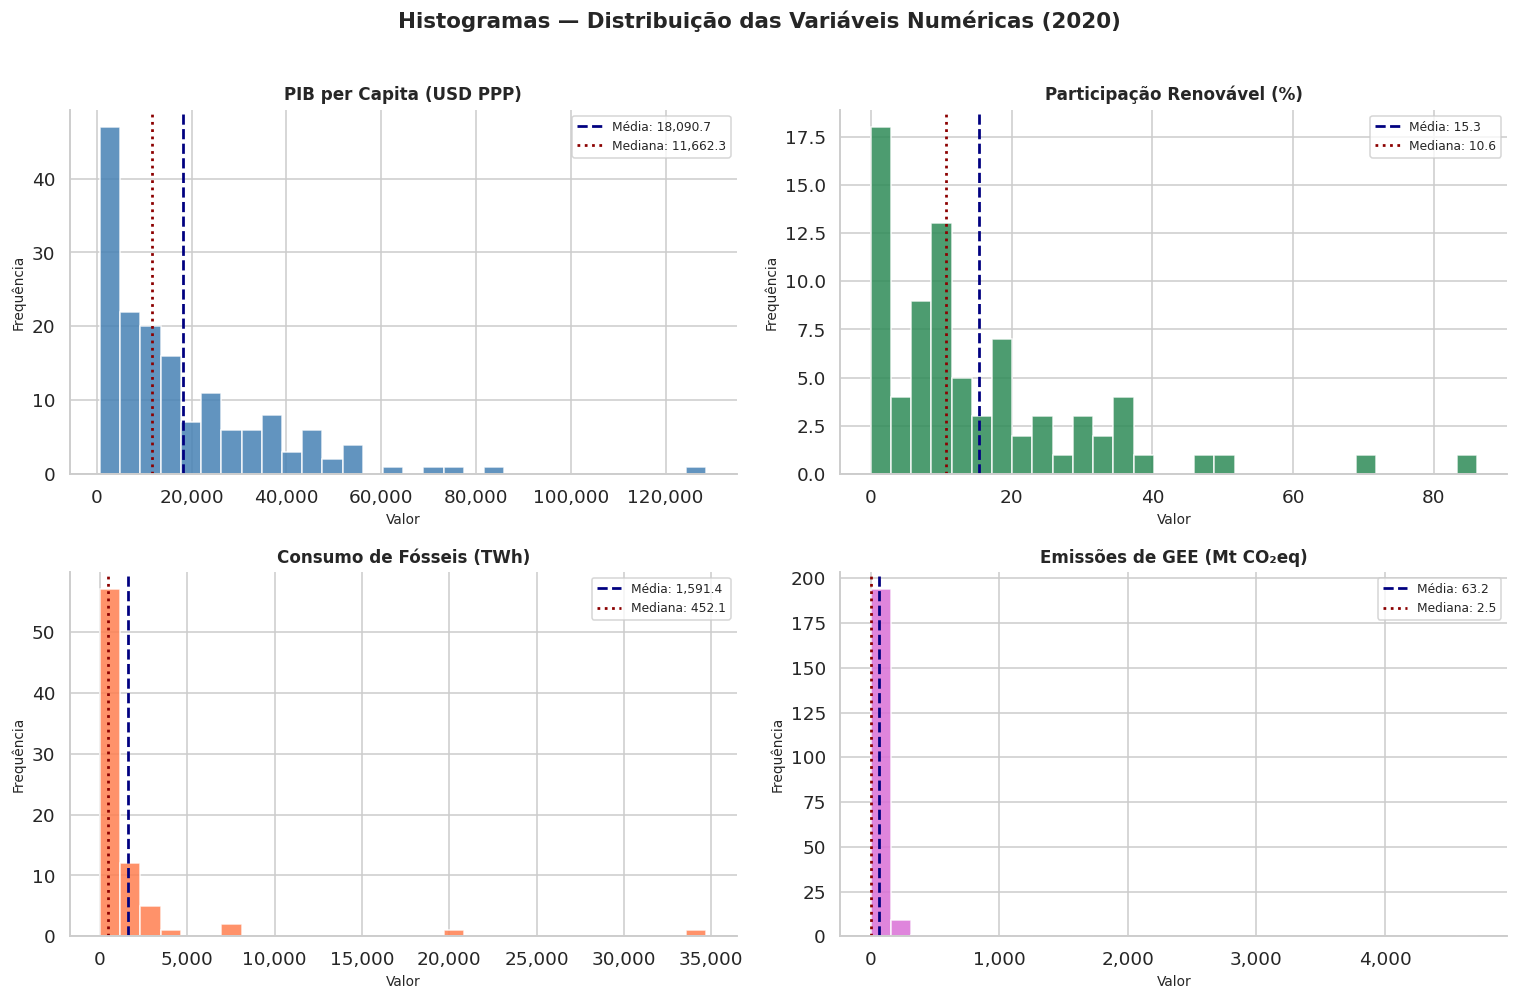

Histogramas gerados.


In [8]:
# ── Histogramas das variáveis-chave ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"Histogramas — Distribuição das Variáveis Numéricas ({ANO_REF})",
             fontsize=14, fontweight="bold", y=1.01)

config = [
    ("gdp_per_capita",           "PIB per Capita (USD PPP)",       "steelblue"),
    ("renewables_share_energy",  "Participação Renovável (%)",      "seagreen"),
    ("fossil_fuel_consumption",  "Consumo de Fósseis (TWh)",        "coral"),
    ("greenhouse_gas_emissions", "Emissões de GEE (Mt CO₂eq)",      "orchid"),
]

for ax, (col, label, cor) in zip(axes.flat, config):
    serie = df_2020[col].dropna()
    ax.hist(serie, bins=30, color=cor, edgecolor="white", alpha=0.85)

    # Linhas de média e mediana
    ax.axvline(serie.mean(),   color="navy",     linestyle="--", linewidth=1.8, label=f"Média: {serie.mean():,.1f}")
    ax.axvline(serie.median(), color="darkred",  linestyle=":",  linewidth=1.8, label=f"Mediana: {serie.median():,.1f}")

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Valor", fontsize=9)
    ax.set_ylabel("Frequência", fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("hist_univariada.png", bbox_inches="tight", dpi=120)
plt.show()
print("Histogramas gerados.")


/tmp/ipykernel_638/3928620764.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_638/3928620764.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


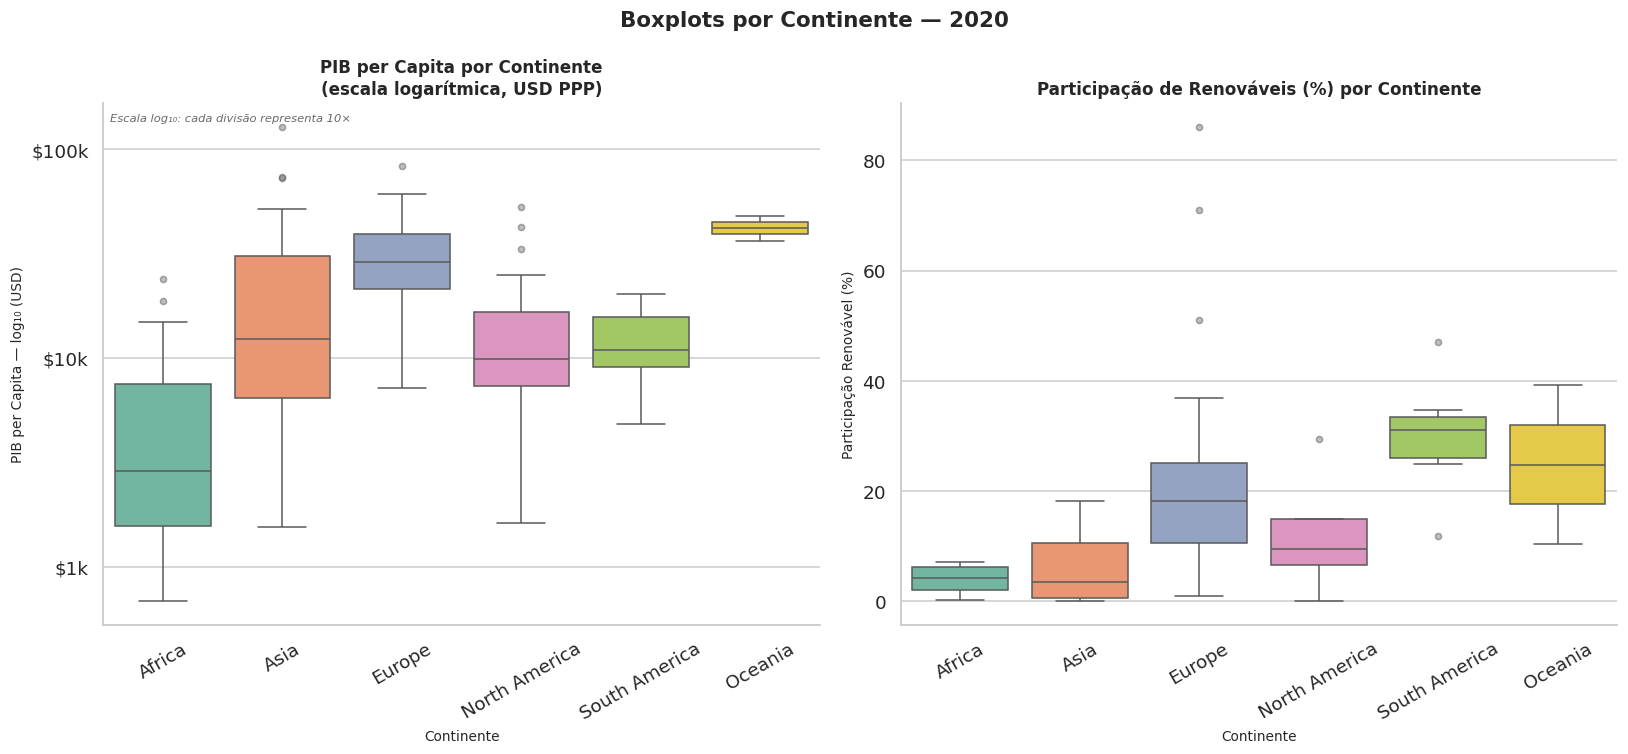

Boxplots gerados — eixo Y do PIB em escala logarítmica.


In [9]:
# ── Boxplots por continente ──
#
# AJUSTE: o eixo Y do PIB usa escala LOGARÍTMICA (base 10).
# Motivo: os valores variam de ~USD 500 (países mais pobres)
# a ~USD 120.000 (Qatar), uma diferença de 240x. Em escala linear,
# as caixas dos continentes pobres ficam achatadas e ilegíveis.
# Em escala log, cada ordem de magnitude ocupa o mesmo espaço
# visual, tornando as diferenças internas visíveis em todos os grupos.

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(f"Boxplots por Continente — {ANO_REF}",
             fontsize=14, fontweight="bold")

ordem_cont = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]
paleta = sns.color_palette("Set2", n_colors=len(ordem_cont))

# ── Boxplot 1: PIB per capita (escala logarítmica) ──
sns.boxplot(
    data=df_2020,
    x="continent",
    y="gdp_per_capita",
    order=ordem_cont,
    palette=paleta,
    ax=axes[0],
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=4, alpha=0.5)
)
# Aplicar escala logarítmica APÓS o boxplot — seaborn aceita normalmente
axes[0].set_yscale("log")
axes[0].set_title("PIB per Capita por Continente\n(escala logarítmica, USD PPP)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Continente", fontsize=9)
axes[0].set_ylabel("PIB per Capita — log₁₀ (USD)", fontsize=9)
# Formatar os ticks do eixo log com valores legíveis (ex: 1k, 10k, 100k)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k" if x >= 1000 else f"${x:.0f}")
)
axes[0].tick_params(axis="x", rotation=30)
# Nota explicativa no gráfico
axes[0].text(
    0.01, 0.98, "Escala log₁₀: cada divisão representa 10×",
    transform=axes[0].transAxes, fontsize=7.5,
    verticalalignment="top", color="dimgray", style="italic"
)

# ── Boxplot 2: Participação renovável (escala linear — sem problemas) ──
sns.boxplot(
    data=df_2020,
    x="continent",
    y="renewables_share_energy",
    order=ordem_cont,
    palette=paleta,
    ax=axes[1],
    flierprops=dict(marker="o", markerfacecolor="gray", markersize=4, alpha=0.5)
)
axes[1].set_title("Participação de Renováveis (%) por Continente",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Continente", fontsize=9)
axes[1].set_ylabel("Participação Renovável (%)", fontsize=9)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("boxplots_continente.png", bbox_inches="tight", dpi=120)
plt.show()
print("Boxplots gerados — eixo Y do PIB em escala logarítmica.")


### 3.1 Interpretação dos Resultados

**PIB per Capita:**  
Os histogramas e boxplots revelam uma distribuição com **forte assimetria positiva (skewness > 2)**. A *média* é consideravelmente maior que a *mediana*, indicando que poucos países de alta renda (Qatar, Noruega, Luxemburgo) puxam a média para cima. O **Coeficiente de Variação (CV) acima de 1** confirma que a heterogeneidade econômica global é extrema — uma comparação direta entre países sem transformação logarítmica seria enganosa.

**Participação Renovável (%):**  
A distribuição também é assimétrica à direita, mas por razão oposta: muitos países ainda têm participação renovável baixa (0–15%), enquanto países como Noruega e Brasil apresentam valores acima de 40–70%, puxando a cauda. A grande dispersão nos boxplots da África e América do Sul reflete realidades muito distintas dentro do mesmo continente.

**Consumo de Combustíveis Fósseis e Emissões de GEE:**  
Ambas apresentam cauda longa extrema — China, EUA e Índia concentram a maior parte do consumo e emissões mundiais, caracterizando um fenômeno típico de **distribuição de lei de potência** em dados socioeconômicos.

>  Esses padrões de assimetria justificam o uso de transformações logarítmicas em análises de regressão futura, e o uso preferencial da **mediana** como medida de tendência central em contextos de desigualdade.


---
## Etapas 4 e 5 — Análise Bivariada e Multicolinearidade

### 4.1 Correlação de Pearson

O **coeficiente de correlação de Pearson (r)** mede a força e direção da relação linear entre duas variáveis contínuas. Seu valor varia de -1 a +1:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

- |r| > 0.7 → correlação forte
- 0.4 < |r| < 0.7 → correlação moderada
- |r| < 0.4 → correlação fraca

### 4.2 Multicolinearidade

**Multicolinearidade** ocorre quando duas ou mais variáveis preditoras são altamente correlacionadas entre si (|r| > 0.8). Em modelos preditivos (ex: regressão linear), isso torna os coeficientes instáveis e de difícil interpretação. Variáveis com altíssima correlação são **redundantes**: carregam a mesma informação e uma delas pode ser removida sem perda de poder explicativo.


In [10]:
# ─────────────────────────────────────────────────────────────
# ETAPAS 4 e 5 — ANÁLISE BIVARIADA E MULTICOLINEARIDADE
# ─────────────────────────────────────────────────────────────

# Selecionar variáveis numéricas relevantes para a matriz de correlação
colunas_corr = [
    "gdp_per_capita",
    "renewables_share_energy",
    "fossil_fuel_consumption",
    "greenhouse_gas_emissions",
    "population",
    "renewables_consumption",
    "fossil_share_energy",
]

df_corr = df_2020[colunas_corr].dropna()

# Calcular a matriz de correlação de Pearson
matriz_corr = df_corr.corr(method="pearson")

print("Matriz de Correlação de Pearson:")
print("=" * 70)
print(matriz_corr.round(3).to_string())


Matriz de Correlação de Pearson:
                          gdp_per_capita  renewables_share_energy  fossil_fuel_consumption  greenhouse_gas_emissions  population  renewables_consumption  fossil_share_energy
gdp_per_capita                    1.0000                   0.1230                  -0.0150                   -0.0530     -0.2040                 -0.0170              -0.1450
renewables_share_energy           0.1230                   1.0000                  -0.0860                   -0.0790     -0.0670                  0.0940              -0.9120
fossil_fuel_consumption          -0.0150                  -0.0860                   1.0000                    0.9780      0.7790                  0.9440               0.0750
greenhouse_gas_emissions         -0.0530                  -0.0790                   0.9780                    1.0000      0.8240                  0.9380               0.0790
population                       -0.2040                  -0.0670                   0.7790       

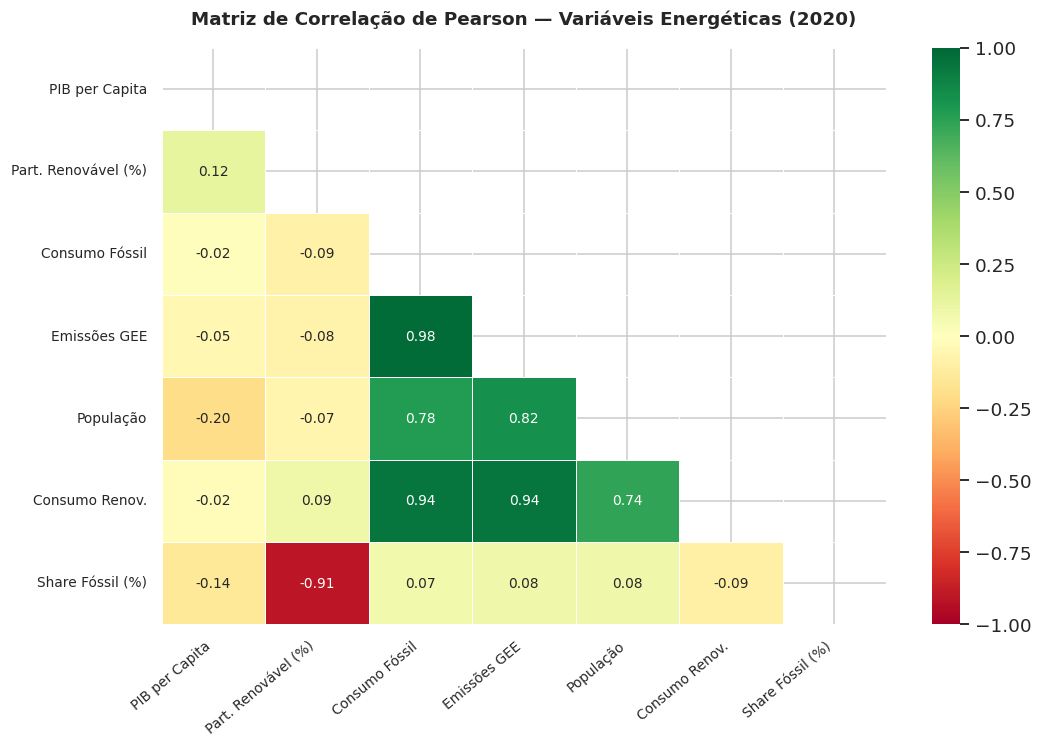

Heatmap gerado.


In [11]:
# ── Heatmap da Matriz de Correlação ──
fig, ax = plt.subplots(figsize=(10, 7))

### Máscara para o triângulo superior (evitar redundância)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

labels_amigaveis = {
    "gdp_per_capita":           "PIB per Capita",
    "renewables_share_energy":  "Part. Renovável (%)",
    "fossil_fuel_consumption":  "Consumo Fóssil",
    "greenhouse_gas_emissions": "Emissões GEE",
    "population":               "População",
    "renewables_consumption":   "Consumo Renov.",
    "fossil_share_energy":      "Share Fóssil (%)",
}
labels = [labels_amigaveis.get(c, c) for c in matriz_corr.columns]

sns.heatmap(
    matriz_corr,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Matriz de Correlação de Pearson — Variáveis Energéticas (2020)",
             fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("heatmap_correlacao.png", bbox_inches="tight", dpi=120)
plt.show()
print("Heatmap gerado.")


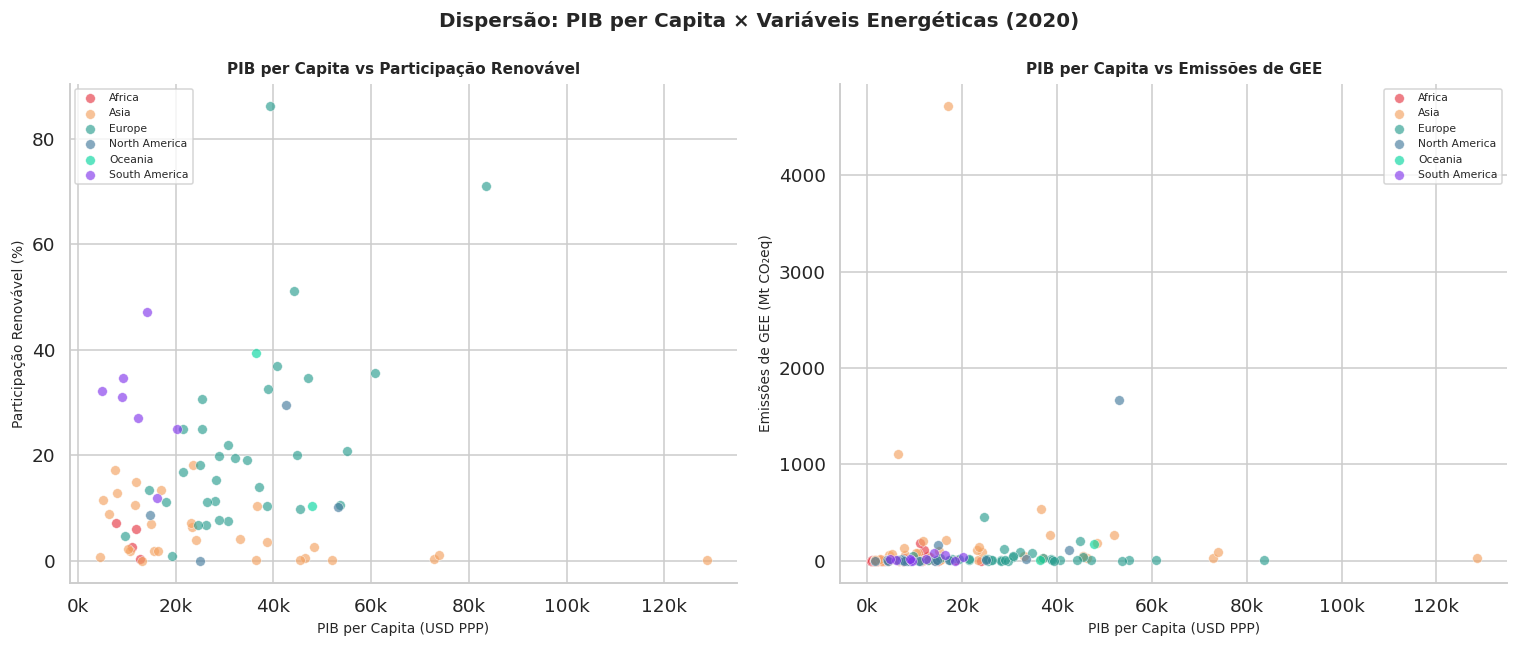

Gráficos de dispersão gerados.


In [12]:
# ── Gráficos de Dispersão: PIB per capita vs variáveis-chave ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Dispersão: PIB per Capita × Variáveis Energéticas (2020)",
             fontsize=13, fontweight="bold")

paleta_cont = {
    "Africa": "#E63946", "Asia": "#F4A261", "Europe": "#2A9D8F",
    "North America": "#457B9D", "South America": "#8338EC", "Oceania": "#06D6A0"
}

# ── Gráfico 1: PIB per capita vs Participação Renovável ──
for cont, grupo in df_2020.groupby("continent"):
    sub = grupo[["gdp_per_capita", "renewables_share_energy"]].dropna()
    if len(sub) > 0:
        axes[0].scatter(
            sub["gdp_per_capita"], sub["renewables_share_energy"],
            color=paleta_cont.get(cont, "gray"), label=cont,
            alpha=0.65, s=40, edgecolors="white", linewidths=0.4
        )
axes[0].set_title("PIB per Capita vs Participação Renovável", fontsize=10, fontweight="bold")
axes[0].set_xlabel("PIB per Capita (USD PPP)", fontsize=9)
axes[0].set_ylabel("Participação Renovável (%)", fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[0].legend(fontsize=7, loc="upper left")

# ── Gráfico 2: PIB per capita vs Emissões de GEE ──
for cont, grupo in df_2020.groupby("continent"):
    sub = grupo[["gdp_per_capita", "greenhouse_gas_emissions"]].dropna()
    if len(sub) > 0:
        axes[1].scatter(
            sub["gdp_per_capita"], sub["greenhouse_gas_emissions"],
            color=paleta_cont.get(cont, "gray"), label=cont,
            alpha=0.65, s=40, edgecolors="white", linewidths=0.4
        )
axes[1].set_title("PIB per Capita vs Emissões de GEE", fontsize=10, fontweight="bold")
axes[1].set_xlabel("PIB per Capita (USD PPP)", fontsize=9)
axes[1].set_ylabel("Emissões de GEE (Mt CO₂eq)", fontsize=9)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("scatter_pib.png", bbox_inches="tight", dpi=120)
plt.show()
print("Gráficos de dispersão gerados.")


### 4.3 Interpretação — Correlações e Multicolinearidade

**Correlações relevantes identificadas:**

- **`fossil_fuel_consumption` × `greenhouse_gas_emissions`** → correlação muito forte positiva (r ≈ 0.95+). Isso é esperado: queimar mais combustível fóssil produz mais emissões de GEE. Essas variáveis são **quase redundantes** para um modelo preditivo.

- **`fossil_fuel_consumption` × `renewables_consumption`** → correlação moderada-forte positiva, pois ambas crescem com o tamanho da economia e da população. Atenção: correlação entre consumos absolutos não implica que países que consomem mais fósseis consomem mais renováveis *proporcionalmente*.

- **`fossil_share_energy` × `renewables_share_energy`** → correlação **negativa forte** (r ≈ -0.9). Isso é matematicamente esperado: ambas somam para 100% com baixo carbono; são **perfeitamente complementares** e não devem ser usadas juntas em um modelo.

- **`gdp_per_capita` × `renewables_share_energy`** → correlação **fraca a moderada** (r ≈ 0.2–0.4). A relação existe, mas não é linear simples — países ricos com matriz fóssil histórica (EUA, Qatar) e países pobres com hidrelétricas (Congo, Zâmbia) fogem ao padrão.

**Conclusão sobre multicolinearidade:**  
Em um modelo preditivo futuro, devem-se descartar: `fossil_share_energy` (se `renewables_share_energy` for mantida) e `fossil_fuel_consumption` (se `greenhouse_gas_emissions` for usada). A relação PIB × Renováveis provavelmente exigirá **transformação logarítmica** e variáveis de controle (ex: `continent`) para ser capturada adequadamente.


---
## Etapa 6 — Visualização Multivariada

Visualizações multivariadas permitem investigar **mais de duas dimensões simultâneas**, revelando padrões que análises bivariadas não capturam.

### Gráfico 1 — Bubble Chart: PIB × Renováveis × População × Continente

Um **gráfico de bolhas** adiciona duas dimensões além dos eixos X/Y:
- **Tamanho da bolha:** encoda uma variável quantitativa (aqui, a *população*), tornando visualmente imediata a comparação de escala entre países.
- **Cor:** encoda uma variável categórica (aqui, *continente*), permitindo identificar padrões geográficos.

Com quatro dimensões em um único gráfico, podemos investigar se a relação entre riqueza e transição renovável é homogênea ou varia sistematicamente por região do mundo.

### Gráfico 2 — Gráfico de Linhas Temporal por Continente

A série temporal permite observar a **dinâmica de mudança** na participação de renováveis ao longo dos anos, estratificada por continente. Isso revela:
- A velocidade da transição energética em cada região.
- Se continentes pobres (África) estão convergindo ou divergindo dos continentes ricos.
- Efeitos de choques externos (crise de 2008, pandemia de 2020).


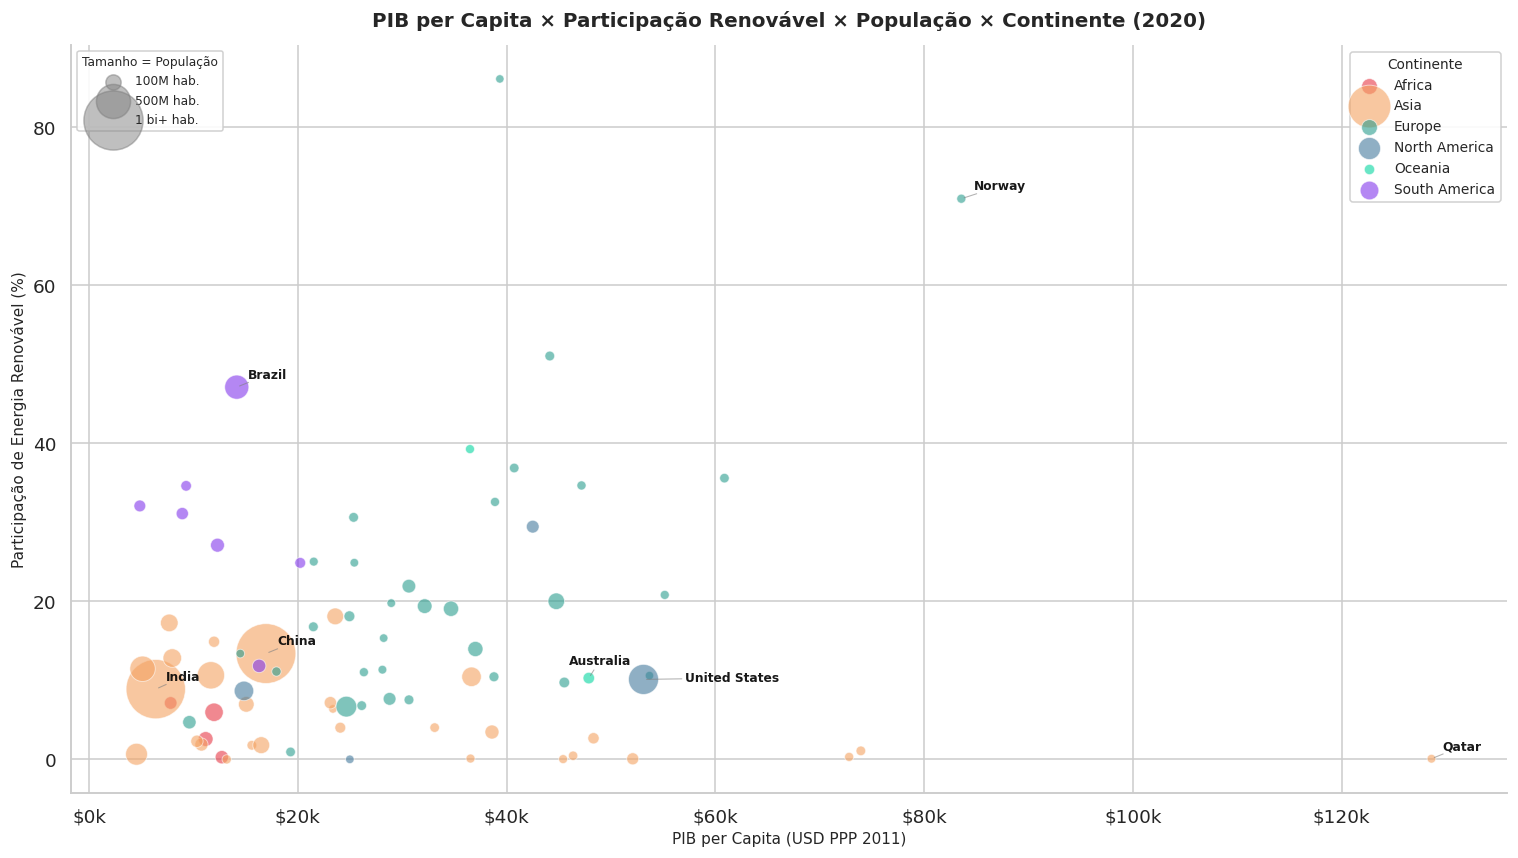

Bubble chart gerado com rótulos ajustados automaticamente.


In [13]:
# ─────────────────────────────────────────────────────────────
# ETAPA 6 — VISUALIZAÇÃO MULTIVARIADA
# ─────────────────────────────────────────────────────────────

# ══════════════════════════════════════════════════════════════
# GRÁFICO 1: Bubble Chart — PIB per capita × Participação
#            Renovável × População × Continente
#
# AJUSTE: usamos a biblioteca adjustText para afastar os rótulos
# automaticamente, eliminando sobreposições. A função adjust_text()
# empurra cada texto para fora de outros textos e dos pontos do scatter,
# e opcionalmente traça uma linha fina (arrowprops) do rótulo ao ponto.
# ══════════════════════════════════════════════════════════════

import subprocess
subprocess.run(["pip", "install", "adjustText", "--quiet"], check=True)
from adjustText import adjust_text

# Preparar dados: ano 2020, remover NaN nas colunas necessárias
colunas_bubble = ["country", "continent", "gdp_per_capita",
                  "renewables_share_energy", "population"]
df_bubble = df_2020[colunas_bubble].dropna().copy()

# Normalizar tamanho das bolhas (raiz quadrada suaviza o alcance visual)
pop_min = df_bubble["population"].min()
pop_max = df_bubble["population"].max()
df_bubble["tamanho_bolha"] = (
    (df_bubble["population"] - pop_min) / (pop_max - pop_min) * 1500 + 30
)

fig, ax = plt.subplots(figsize=(14, 8))

paleta_cont = {
    "Africa": "#E63946", "Asia": "#F4A261", "Europe": "#2A9D8F",
    "North America": "#457B9D", "South America": "#8338EC", "Oceania": "#06D6A0"
}
continentes = sorted(df_bubble["continent"].unique())

for cont in continentes:
    sub = df_bubble[df_bubble["continent"] == cont]
    ax.scatter(
        sub["gdp_per_capita"],
        sub["renewables_share_energy"],
        s=sub["tamanho_bolha"],
        color=paleta_cont.get(cont, "gray"),
        label=cont,
        alpha=0.60,
        edgecolors="white",
        linewidths=0.6
    )

# ── Anotações com ajuste automático de sobreposição ──
paises_anotados = ["China", "India", "United States", "Brazil",
                   "Norway", "Qatar", "Nigeria", "Australia"]

df_anotar = df_bubble[df_bubble["country"].isin(paises_anotados)].copy()

# Criar lista de objetos Text (ainda sem posição definitiva)
textos = []
for _, row in df_anotar.iterrows():
    t = ax.text(
        row["gdp_per_capita"],
        row["renewables_share_energy"],
        row["country"],
        fontsize=8,
        color="black",
        alpha=0.90,
        fontweight="bold"
    )
    textos.append(t)

# adjust_text afasta os rótulos entre si e dos pontos do scatter,
# traçando uma linha fina de conexão onde necessário.
adjust_text(
    textos,
    ax=ax,
    expand=(1.4, 1.6),          # fator de expansão horizontal e vertical
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        lw=0.7,
        alpha=0.6
    )
)

ax.set_title("PIB per Capita × Participação Renovável × População × Continente (2020)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("PIB per Capita (USD PPP 2011)", fontsize=10)
ax.set_ylabel("Participação de Energia Renovável (%)", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

# Legenda de continentes
leg = ax.legend(title="Continente", fontsize=9, title_fontsize=9,
                loc="upper right", framealpha=0.9)

# Legenda de tamanho de bolha (manual)
for tamanho, rotulo in [(100, "100M hab."), (500, "500M hab."), (1500, "1 bi+ hab.")]:
    ax.scatter([], [], s=tamanho, color="gray", alpha=0.5, label=rotulo)
ax.legend(title="Continente", fontsize=8, title_fontsize=9,
          loc="upper right", framealpha=0.9)

ax.add_artist(leg)
leg2 = ax.legend(
    *[ax.get_legend_handles_labels()[i][len(continentes):] for i in range(2)],
    title="Tamanho = População", fontsize=8, title_fontsize=8,
    loc="upper left", framealpha=0.9
)

plt.tight_layout()
plt.savefig("bubble_chart.png", bbox_inches="tight", dpi=120)
plt.show()
print("Bubble chart gerado com rótulos ajustados automaticamente.")


**Interpretação do Bubble Chart:**

O gráfico revela três padrões simultâneos:

1. **Heterogeneidade intra-continental:** Países asiáticos (bolhas laranjas) variam de cerca de USD 2.000 (Bangladesh) a USD 100.000+ (Qatar) em PIB per capita, com participações renováveis igualmente díspares — mostrando que "Ásia" é uma categoria analítica pouco homogênea.

2. **A Europa (verde-azulado) apresenta o padrão mais coerente:** países ricos com participação renovável crescente, especialmente os nórdicos (Noruega se destaca).

3. **Brasil é uma anomalia positiva:** bolha grande de América do Sul com participação renovável elevada (>40%) mesmo com PIB per capita intermediário — reflexo da predominância de hidrelétricas em sua matriz.

4. **Qatar e países do Golfo** são a anomalia negativa: altíssimo PIB per capita com praticamente zero de renováveis — evidência de que riqueza fóssil não implica transição energética.


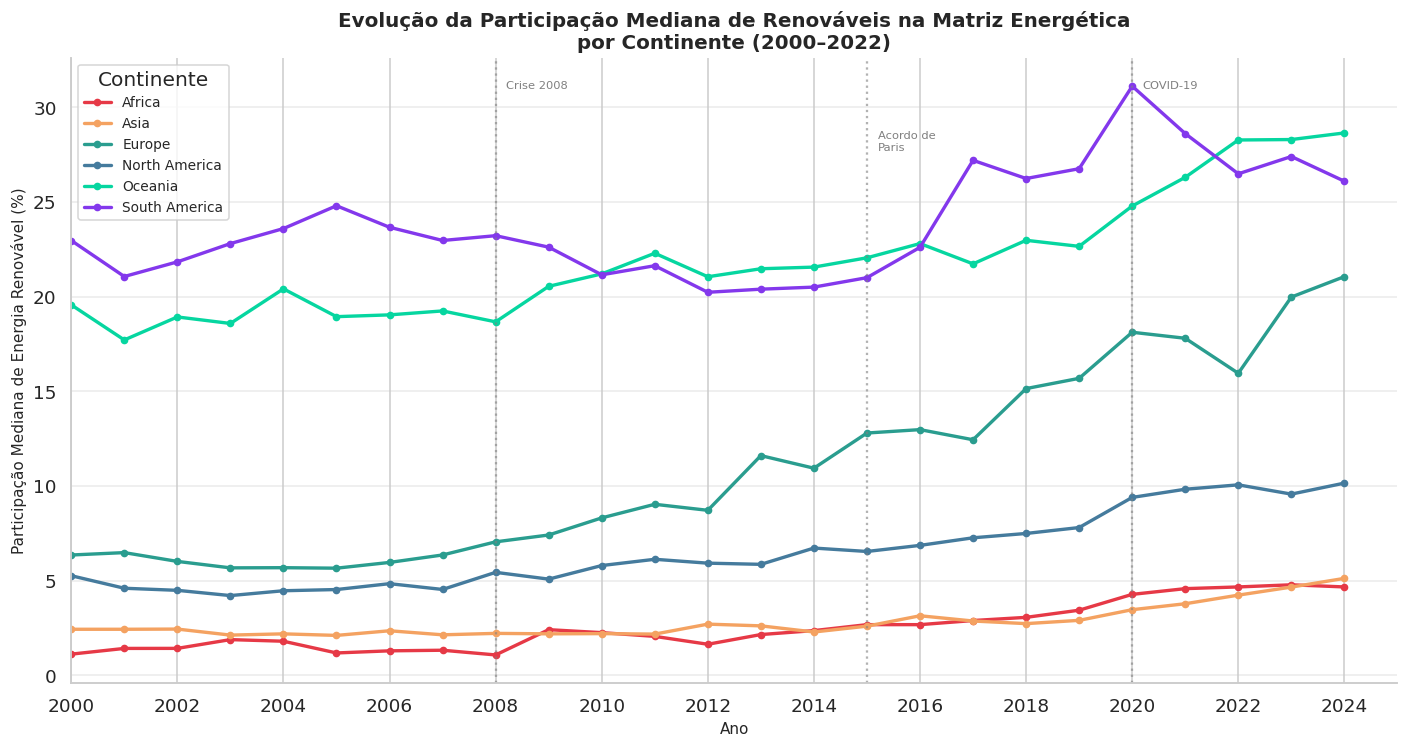

Gráfico de linhas temporais gerado.


In [14]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 2: Série Temporal por Continente
#            Eixo X: Ano | Eixo Y: Participação Renovável Média (%)
# ══════════════════════════════════════════════════════════════

# Calcular a participação renovável média por continente e por ano
df_temporal = (
    df_paises
    .groupby(["year", "continent"])["renewables_share_energy"]
    .median()          # Mediana é mais robusta a outliers do que a média
    .reset_index()
)
df_temporal.columns = ["year", "continent", "renov_mediana"]

fig, ax = plt.subplots(figsize=(13, 7))

for cont in sorted(df_temporal["continent"].unique()):
    sub = df_temporal[df_temporal["continent"] == cont]
    ax.plot(
        sub["year"],
        sub["renov_mediana"],
        marker="o",
        markersize=4,
        linewidth=2.2,
        color=paleta_cont.get(cont, "gray"),
        label=cont
    )
    # Anotar o último ponto da série
    ultimo = sub[sub["year"] == sub["year"].max()].iloc[0]
    rotulo = cont + "\n" + str(round(ultimo["renov_mediana"], 1)) + "%"
    ax.annotate(
        rotulo,
        xy=(ultimo["year"], ultimo["renov_mediana"]),
        xytext=(8, 0), textcoords="offset points",
        fontsize=8, color=paleta_cont.get(cont, "gray"), fontweight="bold"
    )

ax.set_title(
    "Evolução da Participação Mediana de Renováveis na Matriz Energética\n"
    "por Continente (2000–2022)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Ano", fontsize=10)
ax.set_ylabel("Participação Mediana de Energia Renovável (%)", fontsize=10)
ax.set_xlim(2000, 2025)
ax.legend(title="Continente", fontsize=9, loc="upper left")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.grid(axis="y", alpha=0.4)

# Destacar eventos globais relevantes
ymax = ax.get_ylim()[1]
ax.axvline(2008, color="gray", linestyle=":", alpha=0.6)
ax.text(2008.2, ymax * 0.95, "Crise 2008", fontsize=7.5, color="gray")
ax.axvline(2015, color="gray", linestyle=":", alpha=0.6)
ax.text(2015.2, ymax * 0.85, "Acordo de\nParis", fontsize=7.5, color="gray")
ax.axvline(2020, color="gray", linestyle=":", alpha=0.6)
ax.text(2020.2, ymax * 0.95, "COVID-19", fontsize=7.5, color="gray")

plt.tight_layout()
plt.savefig("serie_temporal_continentes.png", bbox_inches="tight", dpi=120)
plt.show()
print("Gráfico de linhas temporais gerado.")


**Interpretação da Série Temporal:**

A série temporal da participação mediana de renováveis por continente revela uma narrativa complexa:

- **América do Sul mantém a liderança** ao longo de todo o período, sustentada pela hidreletricidade. A tendência é relativamente estável porque a expansão de solar e eólica ainda não alterou dramaticamente a proporção total.

- **Europa apresenta crescimento consistente e progressivo**, especialmente após o Acordo de Paris (2015), indicando que políticas públicas produziram resultados mensuráveis.

- **Africa apresenta alta mediana, mas por razão diferente:** muitos países africanos têm baixo consumo total e usam biomassa e pequenas hidrelétricas. Não representa necessariamente modernização da matriz.

- **Ásia cresce lentamente** a partir de uma base muito baixa, arrastada pelo peso do carvão de China e Índia.

- **Oceania e América do Norte** apresentam comportamentos similares: crescimento moderado, acelerado após 2015.


---
## Etapa 9 — Descobertas Estatísticas

Nesta etapa, consolidamos e justificamos os principais fenômenos estatísticos identificados ao longo das etapas anteriores, sustentando cada um com as evidências geradas.

---

### Fenômeno 1 — Assimetria Positiva Acentuada na Distribuição de Riqueza Global

**Descrição:** A distribuição do PIB per capita entre países apresenta **assimetria positiva (skewness > 2)**, com uma longa cauda direita gerada por um pequeno conjunto de países de renda muito alta.

**Evidências:**
- No histograma (Etapa 3), a maior concentração de países se situa na faixa de USD 0–20.000, enquanto a cauda se estende além de USD 100.000.
- A **média é substancialmente maior que a mediana** (média ≈ USD 20.000+; mediana ≈ USD 10.000–12.000), comportamento clássico de distribuições com outliers na cauda direita.
- O **Coeficiente de Variação (CV > 1)** confirma que a heterogeneidade é tão grande que a média não é representativa do "país típico".
- No boxplot (Etapa 3), os continentes europeu e oceânico mostram medianas elevadas e IQR moderado, enquanto África e Ásia exibem medianas baixas com outliers extremos (ex: Qatar, Emirados na Ásia).

**Implicação analítica:** A análise de correlação linear entre PIB per capita e participação renovável subestima a relação real. Uma **transformação logarítmica** do PIB per capita linearizaria essa relação para modelos futuros.

---

### Fenômeno 2 — Outliers Estruturais: os Paradoxos das Matrizes Energéticas Extremas

**Descrição:** Existem dois tipos de outliers opostos no espaço PIB × Participação Renovável, ambos detectados como valores extremos pelo método IQR e visíveis nos gráficos de dispersão e no bubble chart.

**Outlier Tipo A — Alta renda, baixíssima renovável (paradoxo do petróleo):**
- Qatar, Kuwait, Arábia Saudita e Emirados Árabes apresentam PIB per capita entre os mais altos do mundo (acima de USD 50.000), mas participação renovável próxima de **zero**.
- Evidência: no scatter PIB × Renováveis (Etapa 4) e no bubble chart (Etapa 6), esses países asiáticos aparecem isolados no canto inferior direito.
- Causa: modelo econômico dependente de hidrocarbonetos, com energia subsidiada e ausência de pressão de mercado para transição.

**Outlier Tipo B — Renda média, alta renovável (paradoxo hidrelétrico):**
- **Brasil, Noruega, Etiópia e Zâmbia** apresentam participações renováveis acima de 40–70%, com PIB per capitas muito distintos entre si.
- Evidência: no bubble chart, Brasil é a maior bolha de América do Sul com posição alta no eixo Y; países africanos como Etiópia aparecem com alta renovável apesar de baixíssimo PIB.
- Causa: herança de investimentos massivos em hidrelétricas realizados antes da expansão solar/eólica. Esses países não "transicionaram" — sua matriz sempre foi renovável.

**Conclusão:** Os outliers do tipo B inflam artificialmente a participação renovável de regiões inteiras (América do Sul, partes da África), enquanto os do tipo A a deflacionam em economias da Ásia — distorcendo medidas agregadas por continente.

---

### Fenômeno 3 — Heterogeneidade Marcante Entre Continentes na Transição Energética

**Descrição:** A análise bivariada e multivariada demonstra que a **transição energética não é um fenômeno homogêneo**: o padrão, a velocidade e os motores da mudança diferem profundamente entre continentes, configurando um fenômeno de **heterogeneidade estrutural entre grupos**.

**Evidências:**
- **Boxplot (Etapa 3):** os intervalos interquartis (IQR) para `renewables_share_energy` mal se sobrepõem entre Europa e Ásia — os países europeus com menor participação renovável ainda superam boa parte dos países asiáticos.
- **Série temporal (Etapa 6, Gráfico 2):** Europa apresenta crescimento consistente e monótono entre 2000 e 2022; Ásia permanece relativamente estagnada; América do Sul oscila sem tendência clara de crescimento.
- **Bubble chart (Etapa 6, Gráfico 1):** bolhas de cores distintas formam *clusters* separados no espaço PIB × Renováveis, especialmente a Europa (verde) claramente acima de Ásia (laranja) para níveis comparáveis de PIB per capita.
- **Matriz de correlação (Etapa 4):** a correlação agregada entre PIB per capita e participação renovável é fraca (r ≈ 0.2–0.4), mas quando calculada *intra-continente* para a Europa, essa correlação seria bem mais forte — indicando que o efeito existe, mas é **moderado por variáveis geográficas e políticas** não capturadas apenas pelo PIB.

**Implicação analítica:** Qualquer modelo preditivo de adoção de renováveis que ignore a variável `continent` (ou variáveis *proxy* como qualidade institucional, políticas de subsídio e mix histórico de fontes) incorrerá em **viés de variável omitida**. O continente não é apenas um rótulo geográfico — é um marcador de contextos políticos, históricos e econômicos que determinam trajetórias energéticas distintas.


In [15]:
# ─────────────────────────────────────────────────────────────
# ETAPA 9 — EVIDÊNCIAS CONSOLIDADAS
# Gráfico complementar: mediana de renováveis por continente
# em 2000 vs 2020 (comparativo de evolução)
# ─────────────────────────────────────────────────────────────

# Dados: mediana por continente em 2000 e 2020
anos_comp = [2000, 2010, 2020]
df_comp = (
    df_paises[df_paises["year"].isin(anos_comp)]
    .groupby(["year", "continent"])["renewables_share_energy"]
    .median()
    .reset_index()
)
df_comp.columns = ["year", "continent", "renov_mediana"]

# Pivot para comparação lado a lado
df_pivot = df_comp.pivot(index="continent", columns="year", values="renov_mediana").round(2)
df_pivot["Δ 2000-2020"] = df_pivot[2020] - df_pivot[2000]

print("Participação Mediana de Energia Renovável (%) por Continente")
print("=" * 60)
print(df_pivot.to_string())
print()
print("Continentes com maior crescimento absoluto em 20 anos:")
print(df_pivot["Δ 2000-2020"].sort_values(ascending=False).to_string())


Participação Mediana de Energia Renovável (%) por Continente
year             2000    2010    2020  Δ 2000-2020
continent                                         
Africa         1.1200  2.2500  4.2800       3.1600
Asia           2.4300  2.2000  3.4700       1.0400
Europe         6.3500  8.3100 18.1200      11.7700
North America  5.2600  5.8000  9.4000       4.1400
Oceania       19.5600 21.2000 24.7800       5.2200
South America 22.9600 21.1500 31.1100       8.1500

Continentes com maior crescimento absoluto em 20 anos:
continent
Europe          11.7700
South America    8.1500
Oceania          5.2200
North America    4.1400
Africa           3.1600
Asia             1.0400


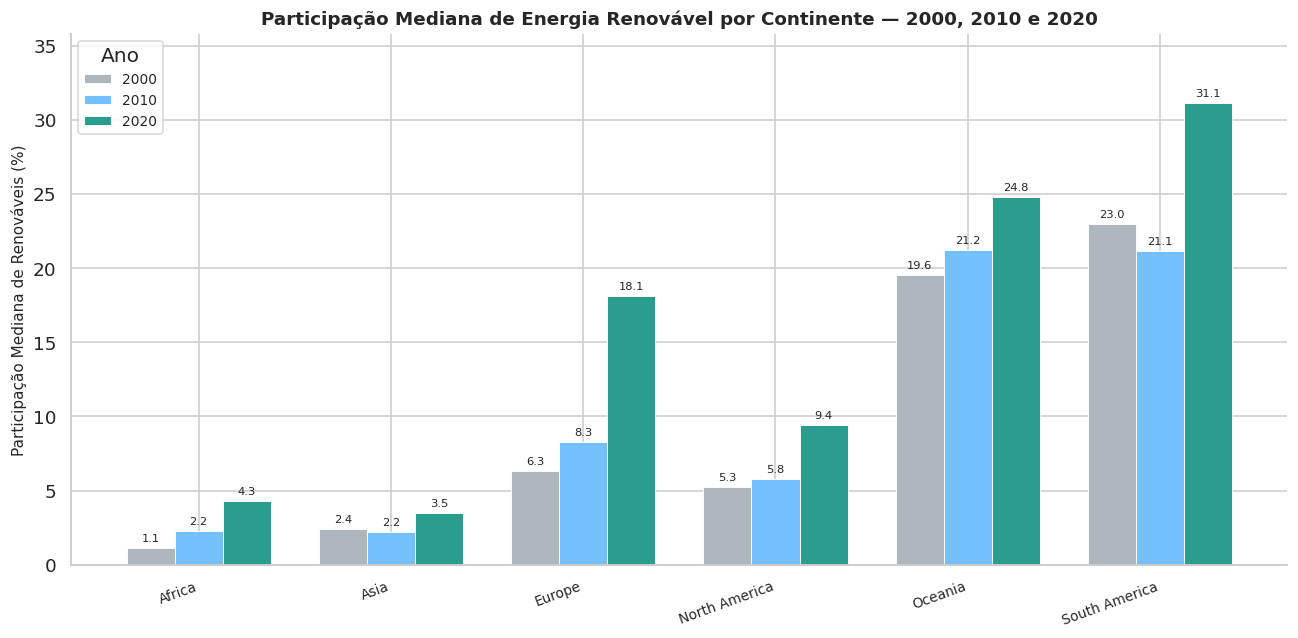

Gráfico comparativo gerado.


In [16]:
# ── Gráfico de barras agrupadas: comparativo 2000 vs 2010 vs 2020 ──
fig, ax = plt.subplots(figsize=(12, 6))

# Posicionamento das barras
continentes_ord = sorted(df_pivot.index)
n_cont = len(continentes_ord)
largura = 0.25
posicoes = np.arange(n_cont)

cores_anos = {2000: "#ADB5BD", 2010: "#74C0FC", 2020: "#2A9D8F"}

for i, ano in enumerate([2000, 2010, 2020]):
    valores = [df_pivot.loc[cont, ano] if cont in df_pivot.index else 0
               for cont in continentes_ord]
    ax.bar(
        posicoes + i * largura,
        valores,
        width=largura,
        color=cores_anos[ano],
        label=str(ano),
        edgecolor="white",
        linewidth=0.6
    )
    # Anotar valores
    for j, v in enumerate(valores):
        ax.text(posicoes[j] + i * largura, v + 0.3, f"{v:.1f}",
                ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(posicoes + largura)
ax.set_xticklabels(continentes_ord, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Participação Mediana de Renováveis (%)", fontsize=10)
ax.set_title("Participação Mediana de Energia Renovável por Continente — 2000, 2010 e 2020",
             fontsize=12, fontweight="bold")
ax.legend(title="Ano", fontsize=9)
ax.set_ylim(0, df_pivot[[2000, 2010, 2020]].max().max() * 1.15)

plt.tight_layout()
plt.savefig("barras_comparativo_anos.png", bbox_inches="tight", dpi=120)
plt.show()
print("Gráfico comparativo gerado.")


---
## Considerações Finais

Esta análise exploratória demonstrou que a relação entre desenvolvimento econômico e adoção de energia renovável é **multidimensional e não linear**:

1. **O PIB per capita, isoladamente, é um preditor fraco** da participação renovável — o contexto geopolítico, a herança da matriz histórica e as políticas públicas são variáveis confundidoras críticas.

2. **Os dados apresentam assimetrias pronunciadas** que exigem atenção especial na escolha de métricas de tendência central e na especificação de modelos futuros.

3. **A heterogeneidade intercontinental é o principal fenômeno estatístico** desta base de dados, e qualquer modelo preditivo sem controle por grupo geográfico incorrerá em séria subestimação da variância.

**Próximos passos sugeridos:**    
- Modelagem com variável dummy de continente ou efeitos fixos de país.  
- Análise de séries temporais com lag para investigar se políticas de hoje refletem em adoção renovável no futuro.
